# Análise Estatística de Métricas On-Chain do Bitcoin

Notebook complementar ao TCC — contém três blocos de análise quantitativa sobre a relação entre métricas on-chain e o preço do Bitcoin.

**Dataset**: `files/blockchain_com/btc_onchain_enriched.csv` (dados diários, agregados para frequência semanal)  
**Período**: 2017–2026  
**Bibliotecas**: `pandas`, `numpy`, `statsmodels`, `sklearn`, `matplotlib`

| Parte | Técnica | Objetivo |
|-------|---------|----------|
| 1 | Regressão Linear Múltipla (OLS com log) | Estimar elasticidades e significância estatística |
| 2 | Regressão Lasso (regularização L1) | Seleção automática de variáveis + ranking de importância |
| 3 | Clusterização K-Means | Identificar regimes de mercado via métricas on-chain |

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Carregamento e Preparação dos Dados

O dataset enriquecido é gerado por `blockchain_explorer.ipynb` e contém métricas on-chain diárias.  
Para reduzir ruído e autocorrelação, os dados são agregados em **frequência semanal** (resample `W`).

In [11]:
DATA_PATH = "files/blockchain_com/btc_onchain_enriched.csv"
PLOTS_DIR = "files/blockchain_com/plots"
DPI = 300

os.makedirs(PLOTS_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

# --- Reamostragem semanal (mesmo critério do notebook de gráficos) ---
df = df_raw.set_index("date").resample("W").agg({
    "price_usd":               "last",
    "transactions":             "mean",
    "active_addresses":         "mean",
    "hashrate":                 "mean",
    "transaction_volume_btc":   "sum",
    "utxo_creation":            "sum",
    "electricity_cost_per_btc": "mean",
}).reset_index()

# Filtro: análise a partir de 2017 (rede mais madura, dados mais estáveis)
df = df[df["date"] >= "2017-01-01"].copy()

# Renomear para nomes curtos usados na análise
df = df.rename(columns={
    "price_usd":               "price",
    "active_addresses":         "active_addr",
    "transaction_volume_btc":   "volume_btc",
    "utxo_creation":            "utxo_delta",
    "electricity_cost_per_btc": "prod_cost",
})

print(f"Shape: {df.shape}")
print(f"Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nEstatísticas descritivas:")
df.describe().round(2)

Shape: (484, 8)
Período: 2017-01-01 → 2026-04-05

Estatísticas descritivas:


,date,price,transactions,active_addr,hashrate,volume_btc,utxo_delta,prod_cost
count,484,484.00,484.00,484.00,4.840000e+02,484.00,484.00,484.00
mean,2021-08-18 12:00:00,34710.69,340159.24,584642.26,3.013549e+08,969851.03,252683.98,11931.21
min,2017-01-01 00:00:00,821.91,171528.86,393372.71,2.404801e+06,444026.17,-3147024.00,218.76
25%,2019-04-26 06:00:00,8170.53,258816.14,506710.39,5.182443e+07,689796.09,-82707.75,2507.45
50%,2021-08-18 12:00:00,23248.69,310232.00,572773.86,1.553014e+08,833625.33,189417.50,7326.63
75%,2023-12-11 18:00:00,57248.55,385253.96,658183.89,4.896984e+08,1083558.00,423420.50,13744.16
max,2026-04-05 00:00:00,122380.94,734345.43,915150.00,1.141110e+09,3049489.40,4063496.00,44571.33
std,NaN,32451.73,110800.62,99802.71,3.180267e+08,435646.04,888974.53,12795.69


### 1.1 Variáveis da Análise

| Variável | Coluna original | Descrição | Unidade |
|----------|----------------|-----------|----------|
| `price` | `price_usd` | Preço de fechamento semanal | USD |
| `transactions` | `transactions` | Média de transações diárias na semana | count |
| `active_addr` | `active_addresses` | Média de endereços ativos na semana | count |
| `utxo_delta` | `utxo_creation` | Variação líquida semanal do UTXO set | count (±) |
| `volume_btc` | `transaction_volume_btc` | Volume on-chain semanal | BTC |
| `hashrate` | `hashrate` | Hashrate médio semanal | TH/s |
| `prod_cost` | `electricity_cost_per_btc` | Custo de eletricidade por BTC minerado | USD |

**Variáveis excluídas** (redundantes com o preço por construção):  
`cost_per_btc` (≈ preço), `miners_revenue` (≈ preço × block_reward), `transaction_volume_usd` (≈ volume_btc × preço), `difficulty` (≈ hashrate com lag ~2 semanas).

---

# PARTE 1 — Regressão Linear Múltipla (OLS com Transformação Logarítmica)

## Fundamentação

A transformação log-log é padrão em econometria financeira por três razões:

1. **Linearização**: séries financeiras e de rede tendem a relações multiplicativas (potência), não aditivas. O log as lineariza.
2. **Estabilização da variância**: reduz heteroscedasticidade inerente a séries com magnitudes muito distintas (preço: $1K–$100K vs. hashrate: 10⁶–10¹¹).
3. **Interpretação econômica**: coeficientes β representam **elasticidades** — "se X aumenta 1%, o preço muda β%".

### Modelo

$$\ln(\text{price}_t) = \beta_0 + \beta_1 \ln(\text{transactions}_t) + \beta_2 \ln(\text{active\_addr}_t) + \beta_3 \cdot \text{IHS}(\text{utxo\_delta}_t) + \beta_4 \ln(\text{volume\_btc}_t) + \beta_5 \ln(\text{hashrate}_t) + \beta_6 \ln(\text{prod\_cost}_t) + \varepsilon_t$$

**Nota sobre `utxo_delta`**: como a variação do UTXO set inclui valores negativos, utiliza-se a transformação **IHS** (seno hiperbólico inverso), $\text{IHS}(x) = \ln(x + \sqrt{x^2 + 1})$, que se comporta como o log natural para valores positivos grandes, mas aceita valores negativos e zero (Burbidge et al., 1988).

In [12]:
# --- Transformação logarítmica ---

# Variáveis estritamente positivas → log natural
log_cols = ["price", "transactions", "active_addr", "volume_btc", "hashrate", "prod_cost"]

# utxo_delta pode ser negativo → usar IHS (inverse hyperbolic sine)
# IHS(x) = ln(x + sqrt(x² + 1)) — equivale a log para valores positivos grandes,
# mas aceita negativos e zero (Burbidge et al., 1988)

df_model = df[["date"] + log_cols + ["utxo_delta"]].copy()

# Remover linhas com valores inválidos (zero ou negativos nas colunas que precisam de log)
for col in log_cols:
    df_model = df_model[df_model[col] > 0]

# Aplicar log natural nas colunas positivas
for col in log_cols:
    df_model[f"ln_{col}"] = np.log(df_model[col])

# Aplicar IHS no utxo_delta
df_model["ihs_utxo_delta"] = np.arcsinh(df_model["utxo_delta"])

# Remover NaN remanescentes
df_model = df_model.dropna()

print(f"Observações disponíveis para regressão: {len(df_model)}")
print(f"Período: {df_model['date'].min().date()} → {df_model['date'].max().date()}")
print(f"\nVariáveis transformadas:")
df_model[[c for c in df_model.columns if c.startswith(('ln_', 'ihs_'))]].describe().round(3)

Observações disponíveis para regressão: 484
Período: 2017-01-01 → 2026-04-05

Variáveis transformadas:


,ln_price,ln_transactions,ln_active_addr,ln_volume_btc,ln_hashrate,ln_prod_cost,ihs_utxo_delta
count,484.000,484.000,484.000,484.000,484.000,484.000,484.000
mean,9.886,12.690,13.264,13.707,18.726,8.676,4.826
std,1.204,0.300,0.169,0.374,1.533,1.373,12.433
min,6.712,12.053,12.883,13.004,14.693,5.388,-15.655
25%,9.008,12.464,13.136,13.444,17.763,7.827,-12.016
50%,10.054,12.645,13.258,13.634,18.861,8.899,12.845
75%,10.955,12.862,13.397,13.896,20.009,9.528,13.649
max,11.715,13.507,13.727,14.930,20.855,10.705,15.911


In [13]:
# --- Regressão OLS com statsmodels ---

# Variável dependente
y = df_model["ln_price"]

# Variáveis independentes (com constante)
feature_cols = [
    "ln_transactions", "ln_active_addr", "ihs_utxo_delta",
    "ln_volume_btc", "ln_hashrate", "ln_prod_cost",
]
X = sm.add_constant(df_model[feature_cols])

# Ajuste do modelo
ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     487.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          5.98e-200
Time:                        16:49:11   Log-Likelihood:                -300.36
No. Observations:                 484   AIC:                             614.7
Df Residuals:                     477   BIC:                             644.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.6696      2.184     

### 1.2 Qualidade de Ajuste e Diagnóstico dos Pressupostos

A validação de um modelo OLS envolve duas etapas:

**A) Métricas de qualidade de ajuste** — avaliam a capacidade preditiva do modelo:
- **R² / R² ajustado** — proporção da variância explicada
- **MAE** (Mean Absolute Error) — erro médio absoluto em unidades de ln(preço)
- **RMSE** (Root Mean Squared Error) — penaliza erros grandes
- **MAPE** (Mean Absolute Percentage Error) — erro percentual médio sobre o preço original

**B) Testes de pressupostos da regressão clássica** — garantem validade das inferências:

| Pressuposto | Teste | H₀ |
|-------------|-------|----|
| Normalidade dos resíduos | Jarque-Bera / Shapiro-Wilk | Resíduos são normais |
| Homocedasticidade | White / Breusch-Pagan | Variância constante |
| Ausência de autocorrelação | Durbin-Watson / Breusch-Godfrey | Sem autocorrelação serial |
| Ausência de multicolinearidade | VIF (Variance Inflation Factor) | VIF < 10 (regra prática) |

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Métricas de qualidade de ajuste ---

y_pred = ols_model.fittedvalues
residuals = ols_model.resid

# Métricas no espaço log
mae_log  = mean_absolute_error(y, y_pred)
rmse_log = np.sqrt(mean_squared_error(y, y_pred))

# MAPE no espaço original (preço em USD)
price_real = np.exp(y)
price_pred = np.exp(y_pred)
mape = np.mean(np.abs((price_real - price_pred) / price_real)) * 100

print("=" * 60)
print("MÉTRICAS DE QUALIDADE DE AJUSTE")
print("=" * 60)
print(f"  R²               {ols_model.rsquared:>12.4f}")
print(f"  R² ajustado       {ols_model.rsquared_adj:>12.4f}")
print(f"  MAE  (ln escala)  {mae_log:>12.4f}")
print(f"  RMSE (ln escala)  {rmse_log:>12.4f}")
print(f"  MAPE (USD)        {mape:>11.2f}%")
print(f"  AIC               {ols_model.aic:>12.1f}")
print(f"  BIC               {ols_model.bic:>12.1f}")
print(f"  Observações       {int(ols_model.nobs):>12d}")

MÉTRICAS DE QUALIDADE DE AJUSTE
  R²                     0.8599
  R² ajustado             0.8581
  MAE  (ln escala)        0.3727
  RMSE (ln escala)        0.4501
  MAPE (USD)              39.91%
  AIC                      614.7
  BIC                      644.0
  Observações                484


In [15]:
from statsmodels.stats.diagnostic import het_white, het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =====================================================================
# A) NORMALIDADE DOS RESÍDUOS
# =====================================================================

# Jarque-Bera (incluso no summary do statsmodels, mas explicitado aqui)
jb_stat, jb_pval, jb_skew, jb_kurt = jarque_bera(residuals)

# Shapiro-Wilk (mais poderoso para amostras < 5000)
sw_stat, sw_pval = shapiro(residuals)

print("=" * 60)
print("A) NORMALIDADE DOS RESÍDUOS")
print("=" * 60)
print(f"\n  Jarque-Bera:")
print(f"    Estatística  = {jb_stat:.4f}")
print(f"    p-valor      = {jb_pval:.4f}")
print(f"    Assimetria   = {jb_skew:.4f}")
print(f"    Curtose      = {jb_kurt:.4f}")
print(f"    → {'Rejeita H0 — resíduos NÃO normais' if jb_pval < 0.05 else 'Não rejeita H0 — resíduos normais'}")

print(f"\n  Shapiro-Wilk:")
print(f"    Estatística  = {sw_stat:.4f}")
print(f"    p-valor      = {sw_pval:.4f}")
print(f"    → {'Rejeita H0 — resíduos NÃO normais' if sw_pval < 0.05 else 'Não rejeita H0 — resíduos normais'}")

# =====================================================================
# B) HOMOCEDASTICIDADE
# =====================================================================

# Teste de White
white_test = het_white(residuals, ols_model.model.exog)
white_labels = ["Estatística LM", "p-valor LM", "Estatística F", "p-valor F"]

# Teste de Breusch-Pagan
bp_stat, bp_pval, bp_fstat, bp_fpval = het_breuschpagan(residuals, ols_model.model.exog)

print("\n" + "=" * 60)
print("B) HOMOCEDASTICIDADE (H0: variância constante)")
print("=" * 60)
print(f"\n  Teste de White:")
for label, val in zip(white_labels, white_test):
    print(f"    {label:<16} = {val:.4f}")
print(f"    → {'Rejeita H0 — heterocedasticidade detectada' if white_test[1] < 0.05 else 'Não rejeita H0 — homocedasticidade'}")

print(f"\n  Teste de Breusch-Pagan:")
print(f"    Estatística LM = {bp_stat:.4f}")
print(f"    p-valor LM     = {bp_pval:.4f}")
print(f"    → {'Rejeita H0 — heterocedasticidade detectada' if bp_pval < 0.05 else 'Não rejeita H0 — homocedasticidade'}")

# =====================================================================
# C) AUTOCORRELAÇÃO DOS RESÍDUOS
# =====================================================================

# Durbin-Watson
dw = durbin_watson(residuals)

# Breusch-Godfrey (testa autocorrelação de ordem superior)
bg_result = acorr_breusch_godfrey(ols_model, nlags=4)
bg_lm, bg_pval, bg_fstat, bg_fpval = bg_result

print("\n" + "=" * 60)
print("C) AUTOCORRELAÇÃO DOS RESÍDUOS")
print("=" * 60)
print(f"\n  Durbin-Watson:")
print(f"    DW = {dw:.4f}")
if dw < 1.5:
    print(f"    → Autocorrelação positiva provável (DW << 2)")
elif dw > 2.5:
    print(f"    → Autocorrelação negativa provável (DW >> 2)")
else:
    print(f"    → Sem autocorrelação forte (DW ≈ 2)")

print(f"\n  Breusch-Godfrey (4 lags):")
print(f"    Estatística LM = {bg_lm:.4f}")
print(f"    p-valor LM     = {bg_pval:.4f}")
print(f"    → {'Rejeita H0 — autocorrelação serial detectada' if bg_pval < 0.05 else 'Não rejeita H0 — sem autocorrelação serial'}")

# =====================================================================
# D) MULTICOLINEARIDADE (VIF)
# =====================================================================

print("\n" + "=" * 60)
print("D) MULTICOLINEARIDADE (VIF)")
print("=" * 60)
print(f"  {'Variável':<25} {'VIF':>8}  {'Status'}")
print(f"  {'-'*50}")

vif_data = []
for i, col in enumerate(feature_cols):
    vif_val = variance_inflation_factor(X.values, i + 1)   # +1 para pular a constante
    status = "⚠ ALTA" if vif_val > 10 else "OK" if vif_val < 5 else "Moderada"
    vif_data.append({"var": col, "vif": vif_val, "status": status})
    labels_pt_local = {
        "ln_transactions": "Transações",
        "ln_active_addr":  "Endereços Ativos",
        "ihs_utxo_delta":  "Variação de UTXOs",
        "ln_volume_btc":   "Volume On-Chain (BTC)",
        "ln_hashrate":     "Hashrate",
        "ln_prod_cost":    "Custo de Produção",
    }
    print(f"  {labels_pt_local[col]:<25} {vif_val:>8.2f}  {status}")

high_vif = [v for v in vif_data if v["vif"] > 10]
if high_vif:
    print(f"\n  ⚠ {len(high_vif)} variável(is) com VIF > 10 — multicolinearidade severa.")
    print("    Os coeficientes individuais podem ser instáveis,")
    print("    embora a capacidade preditiva do modelo não seja afetada.")

A) NORMALIDADE DOS RESÍDUOS

  Jarque-Bera:
    Estatística  = 3.9965
    p-valor      = 0.1356
    Assimetria   = -0.0705
    Curtose      = 2.5778
    → Não rejeita H0 — resíduos normais

  Shapiro-Wilk:
    Estatística  = 0.9930
    p-valor      = 0.0235
    → Rejeita H0 — resíduos NÃO normais

B) HOMOCEDASTICIDADE (H0: variância constante)

  Teste de White:
    Estatística LM   = 217.4547
    p-valor LM       = 0.0000
    Estatística F    = 13.7784
    p-valor F        = 0.0000
    → Rejeita H0 — heterocedasticidade detectada

  Teste de Breusch-Pagan:
    Estatística LM = 108.6770
    p-valor LM     = 0.0000
    → Rejeita H0 — heterocedasticidade detectada

C) AUTOCORRELAÇÃO DOS RESÍDUOS

  Durbin-Watson:
    DW = 0.0781
    → Autocorrelação positiva provável (DW << 2)

  Breusch-Godfrey (4 lags):
    Estatística LM = 449.7962
    p-valor LM     = 0.0000
    → Rejeita H0 — autocorrelação serial detectada

D) MULTICOLINEARIDADE (VIF)
  Variável                       VIF  Status
  

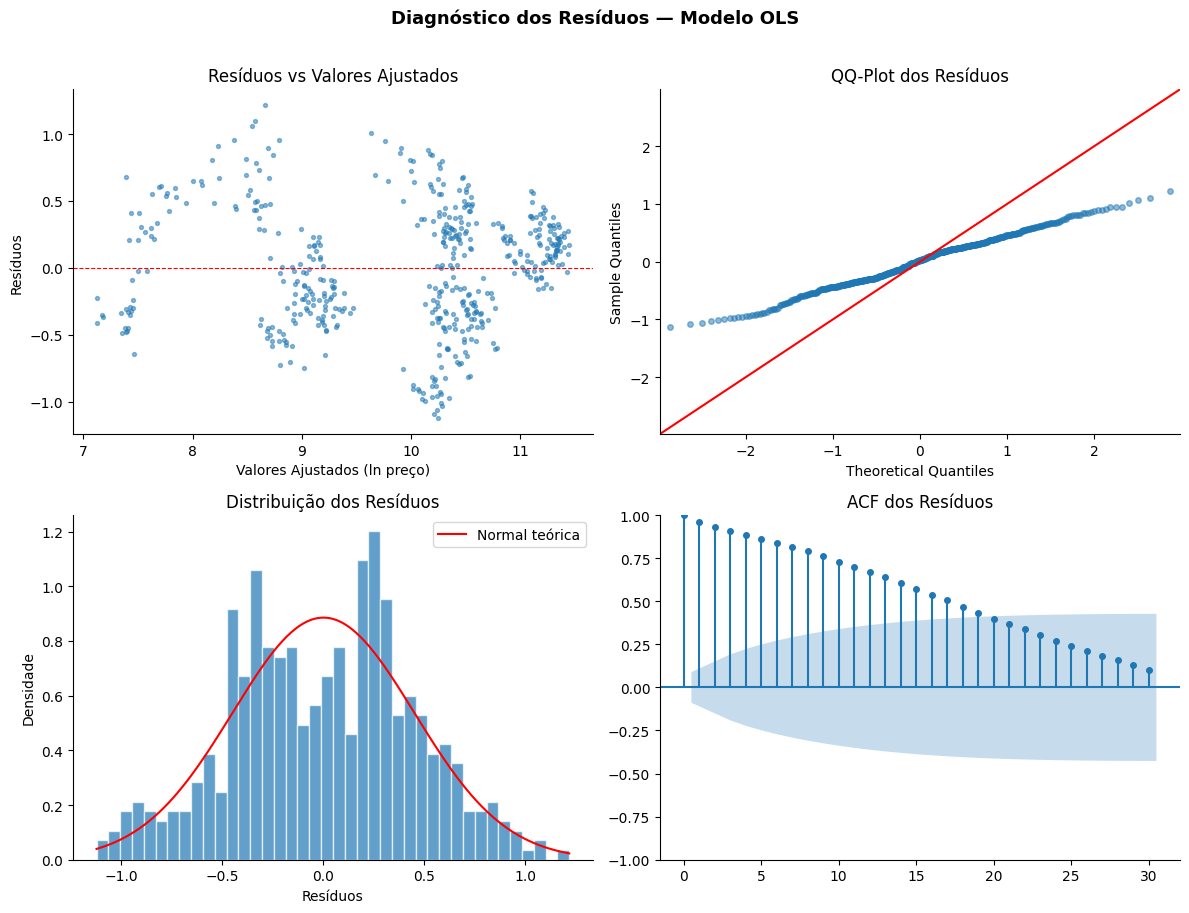

  Salvo: files/blockchain_com/plots/16_ols_residual_diagnostics.png


In [16]:
# --- Gráficos de diagnóstico dos resíduos ---

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1) Resíduos vs Valores Ajustados (detecta heterocedasticidade / padrões)
ax = axes[0, 0]
ax.scatter(y_pred, residuals, s=8, alpha=0.5, color="#1f77b4")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_xlabel("Valores Ajustados (ln preço)")
ax.set_ylabel("Resíduos")
ax.set_title("Resíduos vs Valores Ajustados")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 2) QQ-Plot (normalidade dos resíduos)
ax = axes[0, 1]
sm.qqplot(residuals, line="45", ax=ax, markersize=4, alpha=0.5)
ax.set_title("QQ-Plot dos Resíduos")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 3) Histograma dos resíduos com curva normal teórica
ax = axes[1, 0]
ax.hist(residuals, bins=40, density=True, alpha=0.7, color="#1f77b4", edgecolor="white")
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
from scipy.stats import norm
ax.plot(x_norm, norm.pdf(x_norm, residuals.mean(), residuals.std()),
        color="red", linewidth=1.5, label="Normal teórica")
ax.set_xlabel("Resíduos")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição dos Resíduos")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 4) ACF dos resíduos (autocorrelação)
ax = axes[1, 1]
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=30, ax=ax, alpha=0.05, markersize=4)
ax.set_title("ACF dos Resíduos")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle("Diagnóstico dos Resíduos — Modelo OLS", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "16_ols_residual_diagnostics.png"),
            dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
print(f"  Salvo: {PLOTS_DIR}/16_ols_residual_diagnostics.png")

### 1.3 Correção com Erros Robustos HAC (Newey-West)

Quando os pressupostos de homocedasticidade e/ou ausência de autocorrelação são violados, os **erros-padrão clássicos** da OLS são enviesados — os p-valores e intervalos de confiança ficam incorretos.

A correção **HAC (Heteroskedasticity and Autocorrelation Consistent)** de Newey-West (1987) recalcula a matriz de covariância dos estimadores, produzindo erros-padrão robustos. Os coeficientes β permanecem os mesmos; apenas os erros-padrão e p-valores são corrigidos.

In [17]:
# --- Reestimação com erros robustos HAC (Newey-West) ---

n_lags = int(np.ceil(4 * (len(y) / 100) ** (2/9)))
ols_robust = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": n_lags})

print(f"=== Modelo com Erros Robustos HAC (Newey-West, {n_lags} lags) ===\n")
print(ols_robust.summary())

# --- Tabela comparativa: OLS clássico vs HAC ---
print("\n" + "=" * 70)
print("COMPARAÇÃO: p-valores OLS Clássico vs HAC")
print("=" * 70)

labels_pt_cmp = {
    "ln_transactions": "Transações",
    "ln_active_addr":  "Endereços Ativos",
    "ihs_utxo_delta":  "Variação de UTXOs",
    "ln_volume_btc":   "Volume On-Chain (BTC)",
    "ln_hashrate":     "Hashrate",
    "ln_prod_cost":    "Custo de Produção",
}

def sig_stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return "n.s."

print(f"\n  {'Variável':<25} {'β':>8} {'p (OLS)':>10} {'p (HAC)':>10} {'OLS':>5} {'HAC':>5}")
print(f"  {'-'*63}")
for var in feature_cols:
    coef = ols_model.params[var]
    p_ols = ols_model.pvalues[var]
    p_hac = ols_robust.pvalues[var]
    print(f"  {labels_pt_cmp[var]:<25} {coef:>+8.4f} {p_ols:>10.4f} {p_hac:>10.4f} {sig_stars(p_ols):>5} {sig_stars(p_hac):>5}")

print(f"\n  *** p < 0.01  |  ** p < 0.05  |  * p < 0.10  |  n.s. = não significativo")

=== Modelo com Erros Robustos HAC (Newey-West, 6 lags) ===

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     123.1
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.32e-93
Time:                        16:49:12   Log-Likelihood:                -300.36
No. Observations:                 484   AIC:                             614.7
Df Residuals:                     477   BIC:                             644.0
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [18]:
# --- Síntese do diagnóstico ---

print("=" * 70)
print("SÍNTESE DO DIAGNÓSTICO DO MODELO OLS")
print("=" * 70)

issues = []

# Qualidade de ajuste
print(f"\n📊 QUALIDADE DE AJUSTE")
print(f"  R² = {ols_model.rsquared:.4f} | R² aj. = {ols_model.rsquared_adj:.4f}")
print(f"  MAE = {mae_log:.4f} (ln) | RMSE = {rmse_log:.4f} (ln) | MAPE = {mape:.2f}% (USD)")

# Normalidade
print(f"\n📐 NORMALIDADE DOS RESÍDUOS")
if jb_pval < 0.05 or sw_pval < 0.05:
    print(f"  ✗ Violada — Jarque-Bera p={jb_pval:.4f}, Shapiro-Wilk p={sw_pval:.4f}")
    print(f"    Assimetria = {jb_skew:.3f}, Curtose = {jb_kurt:.3f}")
    issues.append("normalidade")
else:
    print(f"  ✓ Satisfeita — resíduos aproximadamente normais")

# Homocedasticidade
print(f"\n📏 HOMOCEDASTICIDADE")
if white_test[1] < 0.05 or bp_pval < 0.05:
    print(f"  ✗ Violada — White p={white_test[1]:.4f}, Breusch-Pagan p={bp_pval:.4f}")
    issues.append("heterocedasticidade")
else:
    print(f"  ✓ Satisfeita — variância constante dos resíduos")

# Autocorrelação
print(f"\n🔄 AUSÊNCIA DE AUTOCORRELAÇÃO")
if dw < 1.5 or dw > 2.5 or bg_pval < 0.05:
    print(f"  ✗ Violada — DW = {dw:.4f}, Breusch-Godfrey p={bg_pval:.4f}")
    issues.append("autocorrelação")
else:
    print(f"  ✓ Satisfeita — sem autocorrelação serial significativa")

# Multicolinearidade
print(f"\n🔗 MULTICOLINEARIDADE")
if high_vif:
    vars_vif = ", ".join([labels_pt_cmp[v["var"]] for v in high_vif])
    print(f"  ⚠ VIF > 10 em: {vars_vif}")
    print(f"    Coeficientes individuais podem ser instáveis")
    issues.append("multicolinearidade")
else:
    print(f"  ✓ VIF < 10 para todas as variáveis")

# Conclusão
print(f"\n{'=' * 70}")
if issues:
    print(f"⚠ PRESSUPOSTOS VIOLADOS: {', '.join(issues)}")
    if "heterocedasticidade" in issues or "autocorrelação" in issues:
        print(f"  → Erros robustos HAC (Newey-West) foram aplicados para corrigir")
        print(f"    a inferência estatística (p-valores e intervalos de confiança).")
    if "normalidade" in issues:
        print(f"  → A violação de normalidade é comum em séries financeiras e tem")
        print(f"    impacto limitado em amostras grandes (n={int(ols_model.nobs)}) pelo TLC.")
    if "multicolinearidade" in issues:
        print(f"  → Multicolinearidade não viesa os coeficientes, mas aumenta a")
        print(f"    variância dos estimadores. Considerar Lasso para seleção de variáveis.")
else:
    print(f"✓ Todos os pressupostos satisfeitos — inferências da OLS são válidas.")

SÍNTESE DO DIAGNÓSTICO DO MODELO OLS

📊 QUALIDADE DE AJUSTE
  R² = 0.8599 | R² aj. = 0.8581
  MAE = 0.3727 (ln) | RMSE = 0.4501 (ln) | MAPE = 39.91% (USD)

📐 NORMALIDADE DOS RESÍDUOS
  ✗ Violada — Jarque-Bera p=0.1356, Shapiro-Wilk p=0.0235
    Assimetria = -0.071, Curtose = 2.578

📏 HOMOCEDASTICIDADE
  ✗ Violada — White p=0.0000, Breusch-Pagan p=0.0000

🔄 AUSÊNCIA DE AUTOCORRELAÇÃO
  ✗ Violada — DW = 0.0781, Breusch-Godfrey p=0.0000

🔗 MULTICOLINEARIDADE
  ⚠ VIF > 10 em: Hashrate, Custo de Produção
    Coeficientes individuais podem ser instáveis

⚠ PRESSUPOSTOS VIOLADOS: normalidade, heterocedasticidade, autocorrelação, multicolinearidade
  → Erros robustos HAC (Newey-West) foram aplicados para corrigir
    a inferência estatística (p-valores e intervalos de confiança).
  → A violação de normalidade é comum em séries financeiras e tem
    impacto limitado em amostras grandes (n=484) pelo TLC.
  → Multicolinearidade não viesa os coeficientes, mas aumenta a
    variância dos estimadore